In [ ]:
import pandas as pd

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
print(pd.unique(fish['Species']))
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_input.head()

fish_target = fish['Species']

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [ ]:
#train set, test set 만들고 전처리
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled,train_target)
print(kn.score(train_scaled,train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [ ]:
#3개의 이웃을 사용, 확률이 0, 1/3, 2/3, 1로 고정 -> 로지스틱 회귀 도입
print(kn.classes_)
print(kn.predict(test_scaled[:5]))

import numpy as np
proba=kn.predict_proba(test_scaled[:5])
print(np.round(proba,decimals=4))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
['Perch' 'Smelt' 'Pike' 'Perch' 'Perch']
[[0.     0.     1.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     1.     0.    ]
 [0.     0.     0.     1.     0.     0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]
 [0.     0.     0.6667 0.     0.3333 0.     0.    ]]


In [ ]:
char_arr = np.array(['A', 'B', 'C', 'D', 'E'])
print(char_arr[[True, False, True, False, False]])


['A' 'C']


In [ ]:
#train target이 bream or smelt일때만 반환.)
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]


In [ ]:
#bream과 smelt만으로 만들어진 데이터셋으로 로지스틱 회귀모델 훈련 (이진분류)

from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(train_bream_smelt,target_bream_smelt)
print(lr.predict(train_bream_smelt[:5]))

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']


In [ ]:
print(lr.predict_proba(train_bream_smelt[:5]))

[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]


In [ ]:
lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

print(lr.predict(test_scaled[:5]))
proba= lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals = 3))

0.9327731092436975
0.925
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [ ]:
#새로운 데이터가 조금씩 추가된다면... 가장 좋은 방법은 앞서 훈련한 모델에 새로운 데이터에 대해서만
#추가적으로 훈련을 시키자. 점진적 학습.

In [ ]:
import pandas as pd
fish=pd.read_csv('http://bit.ly/fish_csv_data')

fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [ ]:
#확률적 경사하강법 모델 훈련 후 정확도 확인

from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
#partial.fit 메서드: 추가적으로 epoch 1번 더 훈련.
#과소적합 : epoch 너무 적게 돌림
#과대적합 : epoch 너무 많이 돌림

sc.partial_fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.7983193277310925
0.775


In [ ]:
#조기 종료 : epoch별 모델의 정확도 확인 -> 과대 적합 전에 훈련 중지
#SGDClassifier 모델 생성 후 train점수, test점수 리스트 생성

import numpy as np
sc=SGDClassifier(loss='log_loss', random_state = 42)
train_score=[]
test_score=[]
classes = np.unique(train_target)


In [ ]:
for _ in range(0,300):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled,train_target))
  test_score.append(sc.score(test_scaled,test_target))

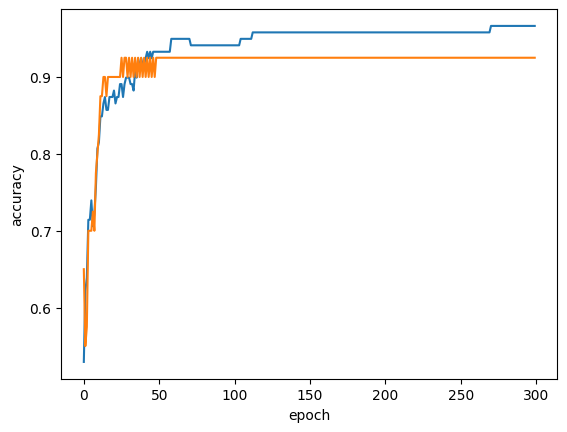

In [ ]:
#epoch 100 이후 훈련 테스트 점수 벌어짐... 100번이 적정하겠다.
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()


In [ ]:
for _ in range(0,100):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled,train_target))
  test_score.append(sc.score(test_scaled,test_target))

In [ ]:
# 1번 과제

#과제 설명: 로지스틱 회귀 모델을 사용해 새로운 데이터셋에 대한 예측 결과 출력
#1. 위의 코드를 사용해 데이터셋을 가져오기

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
#2. 가져온 데이터셋을 테스트 세트와 훈련 세트로 분리 (당연히 먼저 입력과 타깃부터 분리해야겠죠?)

fish_inpit = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_target = fish['Species']

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

In [ ]:
#3. 표준 정규화

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [ ]:
#4. 로지스틱 회귀 모델 훈련

lr = LogisticRegression(C=20, max_iter=1000)
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

print(lr.predict(test_scaled[:5]))
proba= lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals = 3))

0.9327731092436975
0.925
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


In [56]:
#5. 로지스틱 회귀 모델로 새로운 데이터셋 예측값 출력

test_data = np.array([
    [350.0, 29.0, 33.5, 10.50, 4.60],
    [18.5, 12.5, 14.0, 2.30, 1.35],
    [820.0, 41.5, 45.0, 7.80, 5.10],
    [160.0, 21.0, 23.5, 6.20, 3.60],
    [550.0, 26.5, 31.0, 13.80, 6.10]
])

test_data_scaled = ss.transform(test_data) # 훈련 때 사용한 ss 객체로 변환
print(lr.predict(test_data_scaled[:5]))

['Bream' 'Smelt' 'Pike' 'Perch' 'Whitefish']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [59]:
#6. 각 예측 결과에 대한 7종의 물고기 별 확률 출력

print(lr.predict_proba(test_data_scaled[:5]))


[[4.51225317e-01 4.90381346e-02 7.83261720e-03 5.57836048e-03
  3.84373338e-01 1.76138848e-06 1.01950471e-01]
 [5.46495190e-09 1.55452720e-03 4.81382842e-02 4.05707792e-05
  9.43237410e-03 9.40828645e-01 5.59356102e-06]
 [6.55207839e-06 6.26578179e-09 2.87042717e-01 7.12724198e-01
  1.87461109e-04 4.99379621e-07 3.85668215e-05]
 [9.43045494e-05 1.29037943e-02 5.11861862e-01 1.25069325e-03
  4.61149399e-01 1.50062283e-03 1.12393241e-02]
 [3.68253563e-01 9.43070106e-02 3.60736441e-04 1.46743394e-07
  9.03557297e-03 1.14657500e-12 5.28042970e-01]]


In [61]:
# 2번 과제
#과제 설명: SGD classifier 모델을 훈련시키고 최적의 에포크 값을 찾기

#1. 위의 코드를 사용해 데이터셋을 가져오기

fish=pd.read_csv('http://bit.ly/fish_csv_data')
fish_input=fish[['Weight','Length','Diagonal','Height','Width']]
fish_target=fish['Species']

from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(fish_input,fish_target, random_state=42)

from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [62]:
#2. SGDclassifier 모델 훈련 (loss 파라미터는 hinge로 설정, 에포크수는 10으로 설정)

from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='hinge', max_iter=10, random_state=42)
sc.fit(train_scaled,train_target)
print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

train_score=[]
test_score=[]
classes = np.unique(train_target)

for _ in range(0,10):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled,train_target))
  test_score.append(sc.score(test_scaled,test_target))

0.8067226890756303
0.875


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


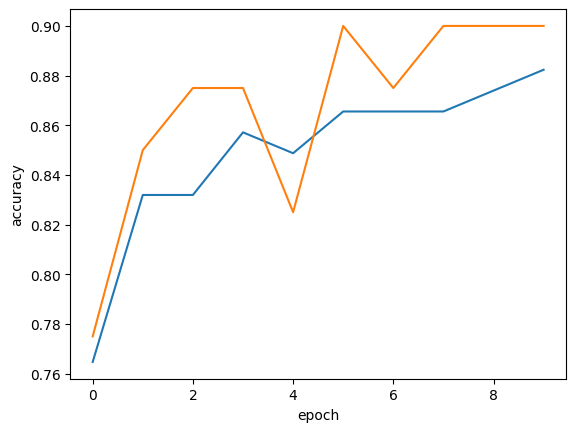

In [63]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

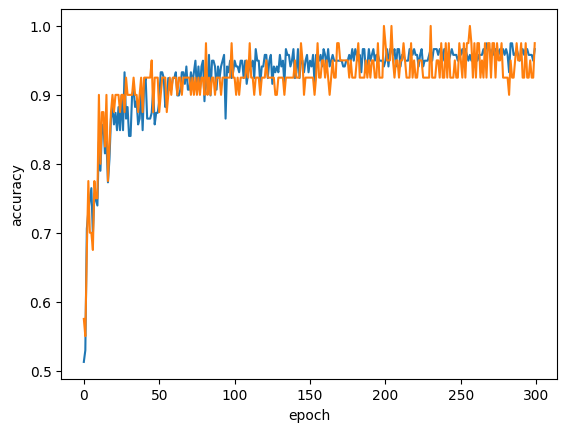

In [65]:
#3. SGDclassifier 모델 훈련 (loss 파라미터는 hinge로 설정, 에포크수는 300으로 설정)
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='hinge', max_iter=10, random_state=42)
train_score=[]
test_score=[]
classes = np.unique(train_target)

for _ in range(0,300):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled,train_target))
  test_score.append(sc.score(test_scaled,test_target))

#5. 에포크를 x축 정확도를 y축으로 하는 matplotlib 그래프 그리기
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

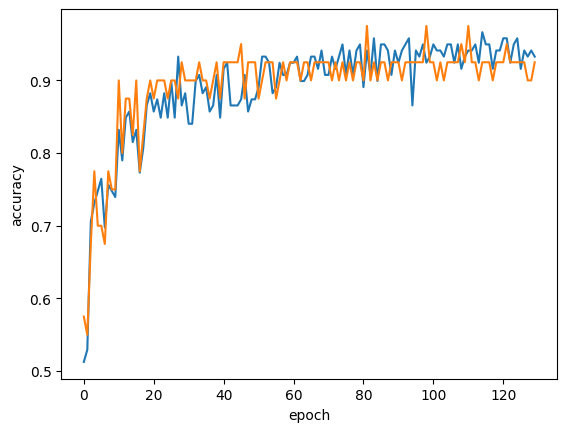

In [68]:
#6. 눈으로 보고 적절한 에포크 수 찾기

from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='hinge', max_iter=10, random_state=42)

train_score=[]
test_score=[]
classes = np.unique(train_target)

for _ in range(0,130):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled,train_target))
  test_score.append(sc.score(test_scaled,test_target))

plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [69]:
#7. 해당 에포크 수로 모델 훈련하고 점수 출력해 2번 과정의 에포크 10인 모델과 정확도 비교
#정확도가 0.8에서 0.9로 나아졌다.

print(sc.score(train_scaled,train_target))
print(sc.score(test_scaled,test_target))

0.9327731092436975
0.925
